In [30]:
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt

from data_processing.loading.dataframe_loading import load_psd
from data_processing.arc_paths import get_parq_root, get_report_root, INPUT_DATA_FOLDER
from data_processing.processing.bimodal_fitting import (
    get_psd_energy_histogram, 
    scan_histogram_slices
)
from data_processing.reporting.plotting import plot_psd_histogram, plot_scatter
from data_processing.dataframe_validation import get_df_col, DataframeColumn

from scipy.signal import savgol_filter, find_peaks, find_peaks_cwt
from scipy.interpolate import UnivariateSpline

In [48]:
# Data location

experiment_name = 'ID-76'
experiment_display_name = 'EJ-309 Magnetic Interference Testing - KOH present, inside reactor chamber, with shield box and metal wall, thruster present'
experiment_name_2 = 'ID-79'
experiment_display_name = 'EJ-309 Magnetic Interference Testing - KOH present, inside reactor chamber, with shield box and metal wall, thruster absent'

In [3]:
# Locations
PARQ_ROOT = get_parq_root(experiment_name)
REPORT_ROOT = get_report_root(experiment_name)

In [4]:
# read first csv into dataframe
# get header from first csv
psd_report = load_psd(experiment_name)

In [5]:
psd_report.head()

,CALIB_ENERGY,ENERGYSHORT,ENERGY,TIMETAG,tail / total
0,1.248560,1606,1784,11883512729,0.099776
1,0.176323,216,248,13676057634,0.129032
2,0.193775,234,273,13961774340,0.142857
3,0.447175,562,636,29463020469,0.116352
4,0.134439,160,188,55144953033,0.148936


In [6]:
energy_spectrum_path = INPUT_DATA_FOLDER / experiment_name / "processed_data/unfiltered/spectra/energy_spectrum_0.parquet"

In [7]:
energy_spectrum = pd.read_parquet(energy_spectrum_path)
energy_spectrum

,channel,count,bin_energy
0,0.0,0,0.003202
1,1.0,1,0.003900
2,2.0,1,0.004598
3,3.0,2,0.005296
4,4.0,0,0.005994
...,...,...,...
4090,4090.0,0,2.858310
4091,4091.0,0,2.859010
4092,4092.0,0,2.859700
4093,4093.0,0,2.860400


In [8]:
energy_channel_array = energy_spectrum['channel']
bin_energy_array = energy_spectrum['bin_energy']

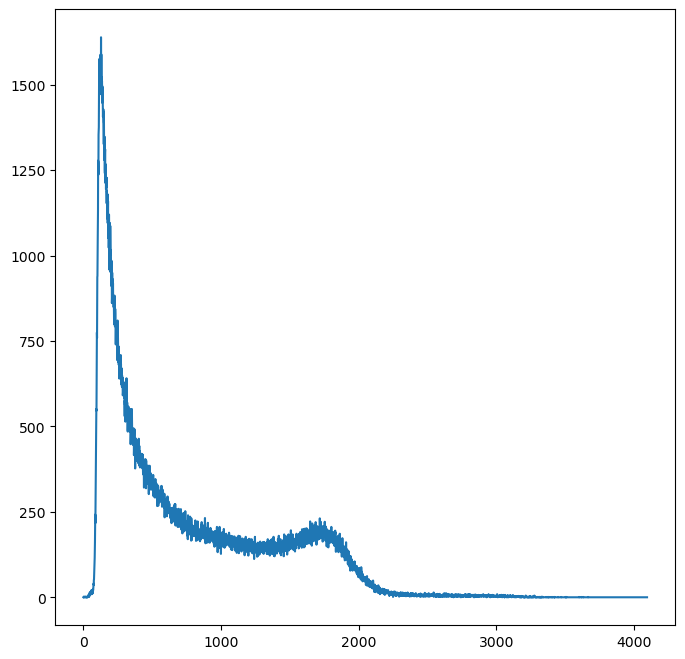

In [9]:
fig, ax = plt.subplots(figsize=(8,8))
ax.plot(energy_channel_array, energy_spectrum['count'])

In [10]:
energy_spectrum_smooth = savgol_filter(energy_spectrum['count'], 51, 7)

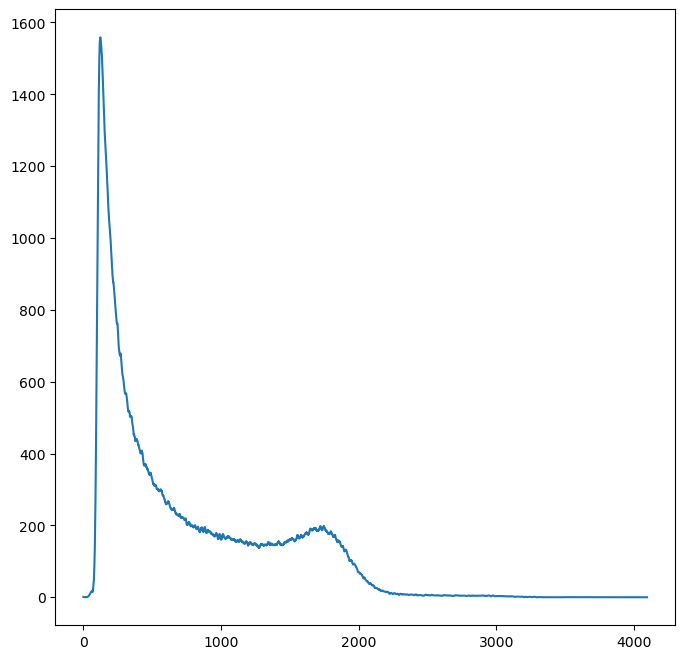

In [12]:
fig, ax = plt.subplots(figsize=(8,8))
ax.plot(energy_channel_array, energy_spectrum_smooth)

In [23]:
# peak finding
peaks, properties = find_peaks(energy_spectrum_smooth, prominence=4, width=100)
print(peaks)
print(properties['prominences'])
print(properties['widths'])

[ 123 1747]
[1558.65336074   60.77727442]
[139.12268806 216.59228737]


In [24]:
k_peak = peaks[-1]
k_peak_energy = bin_energy_array[k_peak]

Text(1.2427300000000001, 1500, 'K peak: 1.22273 MeVee')

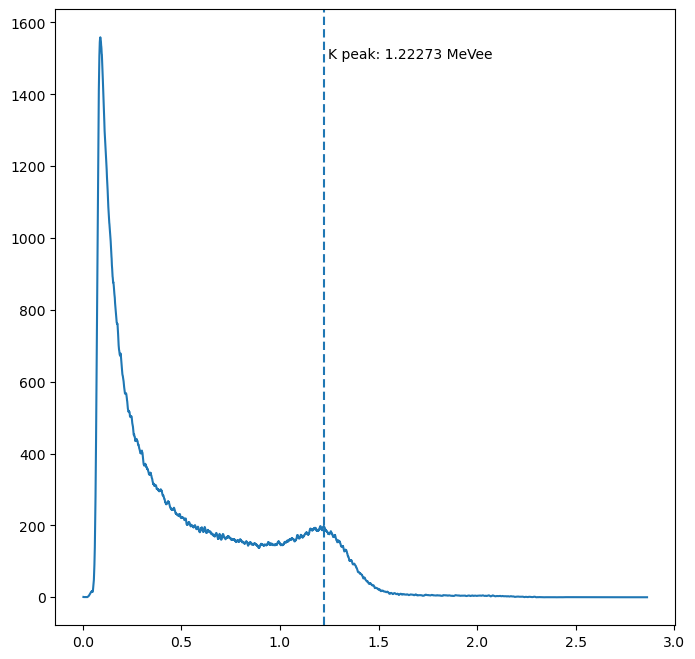

In [26]:
fig, ax = plt.subplots(figsize=(8,8))
ax.plot(bin_energy_array, energy_spectrum_smooth)
ax.axvline(k_peak_energy, dashes=[4,2])
ax.text(k_peak_energy + 0.02, 1500, f"K peak: {k_peak_energy} MeVee")

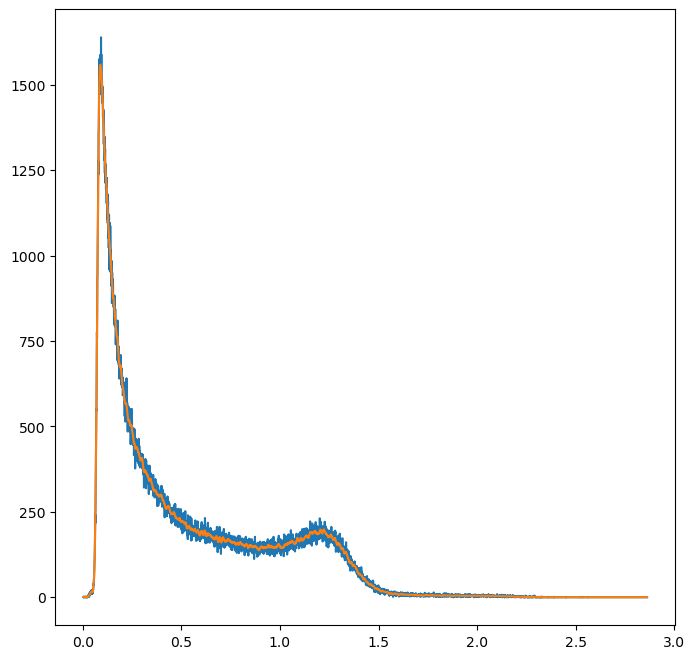

In [47]:
fig, ax = plt.subplots(figsize=(8,8))
ax.plot(bin_energy_array, energy_spectrum['count'])
ax.plot(bin_energy_array, energy_spectrum_smooth)
# ax.axvline(k_peak_energy, dashes=[4,2])
# ax.text(k_peak_energy + 0.02, 1500, f"K peak: {k_peak_energy} MeVee")

In [33]:
cwt_peaks = find_peaks_cwt(energy_spectrum['count'], widths=400)
print(cwt_peaks)
print([bin_energy_array[x] for x in cwt_peaks])

[ 278 1715]
[0.197265, 1.20039]


In [34]:
k_peak_cwt = cwt_peaks[-1]
k_peak_cwt_energy = bin_energy_array[k_peak_cwt]

Text(1.18039, 1250, '1.20039 MeVee')

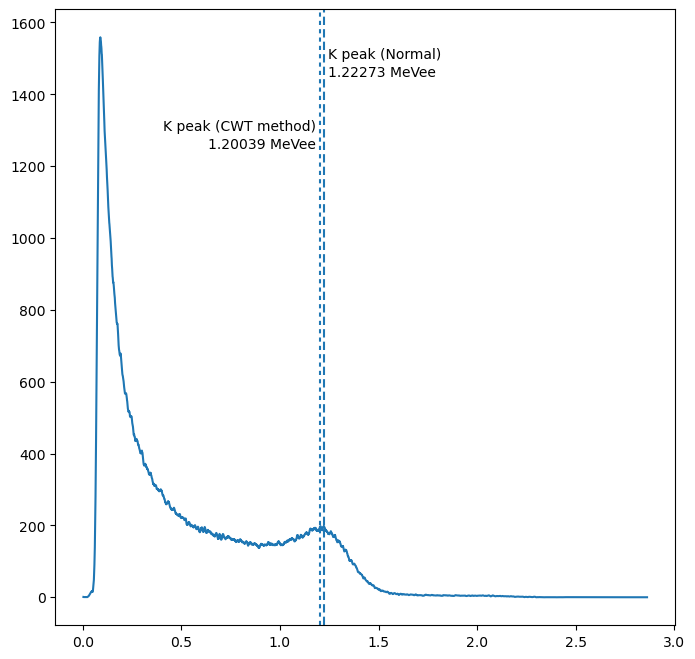

In [45]:
fig, ax = plt.subplots(figsize=(8,8))
ax.plot(bin_energy_array, energy_spectrum_smooth)
ax.axvline(k_peak_energy, dashes=[4,2])
ax.text(k_peak_energy + 0.02, 1500, f"K peak (Normal)")
ax.text(k_peak_energy + 0.02, 1450, f"{k_peak_energy} MeVee")
ax.axvline(k_peak_cwt_energy, dashes=[2,2])
ax.text(k_peak_cwt_energy - 0.02, 1300, f"K peak (CWT method)", horizontalalignment='right')
ax.text(k_peak_cwt_energy - 0.02, 1250, f"{k_peak_cwt_energy} MeVee", horizontalalignment='right')

Text(1.18039, 1250, '1.20039 MeVee')

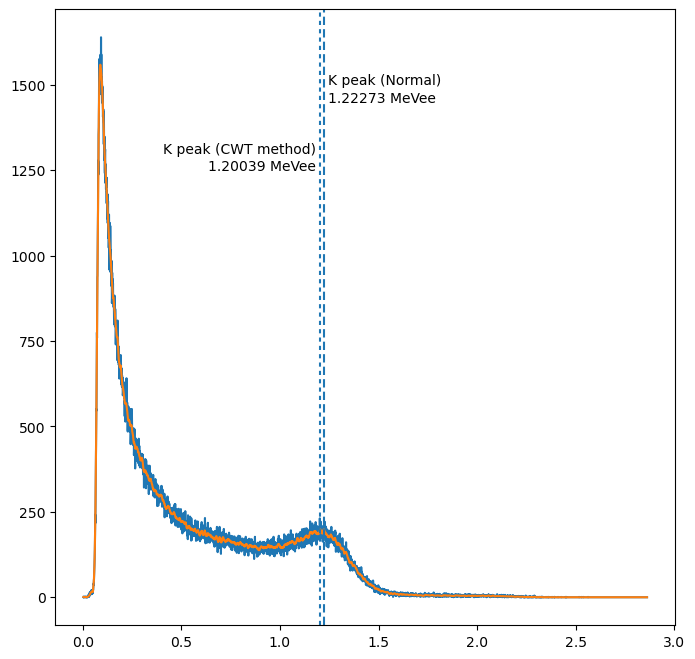

In [49]:
fig, ax = plt.subplots(figsize=(8,8))
ax.plot(bin_energy_array, energy_spectrum['count'])
ax.plot(bin_energy_array, energy_spectrum_smooth)
ax.axvline(k_peak_energy, dashes=[4,2])
ax.text(k_peak_energy + 0.02, 1500, f"K peak (Normal)")
ax.text(k_peak_energy + 0.02, 1450, f"{k_peak_energy} MeVee")
ax.axvline(k_peak_cwt_energy, dashes=[2,2])
ax.text(k_peak_cwt_energy - 0.02, 1300, f"K peak (CWT method)", horizontalalignment='right')
ax.text(k_peak_cwt_energy - 0.02, 1250, f"{k_peak_cwt_energy} MeVee", horizontalalignment='right')

In [66]:
all_exp_details = {
    "ID-76": "KOH, inside, with shield + wall plate, thruster present",
    "ID-79": "KOH, inside, with shield + wall plate, thruster absent",
}
experiment_spectra_paths = {exp_name:INPUT_DATA_FOLDER / exp_name / "processed_data/unfiltered/spectra/energy_spectrum_0.parquet" 
                            for exp_name in all_exp_details}

In [67]:
all_energy_spectra = {exp_name: pd.read_parquet(spectra_path) for exp_name, spectra_path in experiment_spectra_paths.items()}

In [68]:
plot_data = {}
for exp_name, energy_spectrum in all_energy_spectra.items():
    bin_energy_array = energy_spectrum['bin_energy']
    energy_spectrum_smooth = savgol_filter(energy_spectrum['count'], 51, 7)
#     energy_spectrum_spline = UnivariateSpline(bin_energy_array, energy_spectrum_smooth)
#     energy_spectrum_spline_deriv = energy_spectrum_spline.derivative()
    peaks, _ = find_peaks(energy_spectrum_smooth, width=100, prominence=4)
    print(f"{exp_name}: Peaks at indices {peaks}, corresponding to energies {[bin_energy_array[peak] for peak in peaks]}")
    k_peak = bin_energy_array[peaks[-1]]
    peaks = find_peaks_cwt(energy_spectrum_smooth, widths=400)
    print(f"{exp_name}: CWT peaks at indices {peaks}, corresponding to energies {[bin_energy_array[peak] for peak in peaks]}")
    k_peak_cwt = bin_energy_array[peaks[-1]]
    plot_data[exp_name] = {
        "x": bin_energy_array,
        "y": energy_spectrum_smooth,
        "k_peak": k_peak,
        "k_peak_cwt": k_peak_cwt
    }

ID-76: Peaks at indices [ 123 1747], corresponding to energies [0.0890646, 1.22273]
ID-76: CWT peaks at indices [ 278 1715], corresponding to energies [0.197265, 1.20039]
ID-79: Peaks at indices [ 126 1757], corresponding to energies [0.0911588, 1.22971]
ID-79: CWT peaks at indices [ 278 1721], corresponding to energies [0.197265, 1.20458]


In [69]:
for exp_id, details in all_exp_details.items():
    plot_data[exp_id]['exp_description'] = details

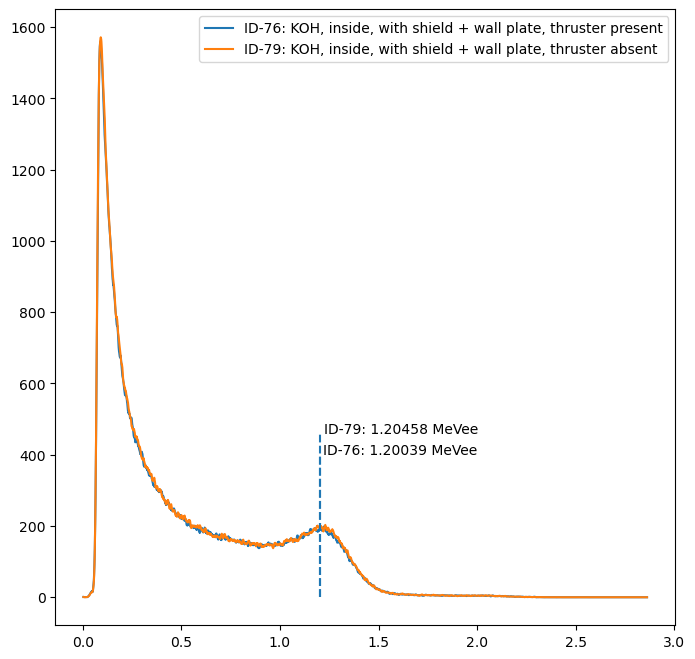

In [70]:
fig, ax = plt.subplots(figsize=(8,8))
for i, (exp_name, plot_series) in enumerate(plot_data.items()):
    ax.plot(plot_series['x'], plot_series['y'], label=f"{exp_name}: {plot_series['exp_description']}")
    k_peak_cwt = plot_series['k_peak_cwt']
    y_pos = 400+i*60
    ax.vlines([k_peak_cwt], linestyle="dashed", ymin=0, ymax=y_pos)
    ax.text(k_peak_cwt + 0.02, y_pos, f"{exp_name}: {k_peak_cwt} MeVee")
ax.legend()

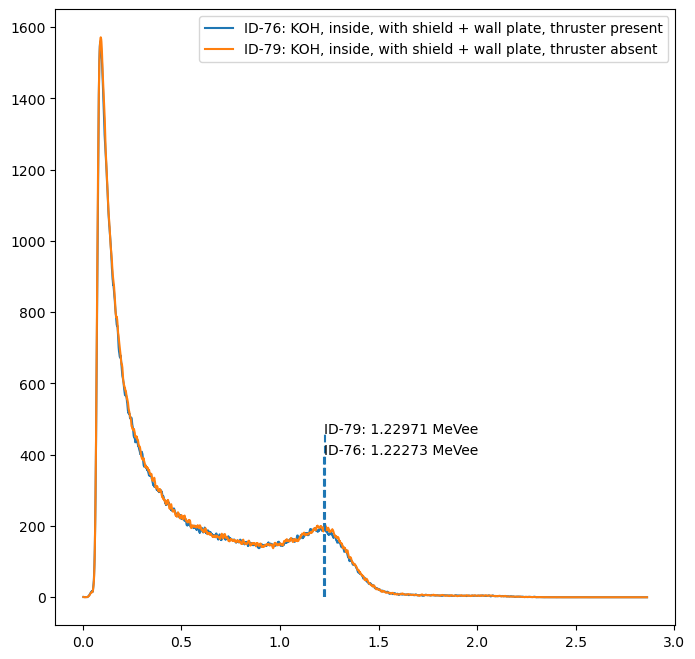

In [71]:
fig, ax = plt.subplots(figsize=(8,8))
for i, (exp_name, plot_series) in enumerate(plot_data.items()):
    ax.plot(plot_series['x'], plot_series['y'], label=f"{exp_name}: {plot_series['exp_description']}")
    k_peak = plot_series['k_peak']
    y_pos = 400+i*60
    ax.vlines([k_peak], linestyle="dashed", ymin=0, ymax=y_pos)
    ax.text(k_peak_cwt + 0.02, y_pos, f"{exp_name}: {k_peak} MeVee")
ax.legend()

In [13]:
energy_spectrum_deriv = np.gradient(energy_spectrum_smooth)

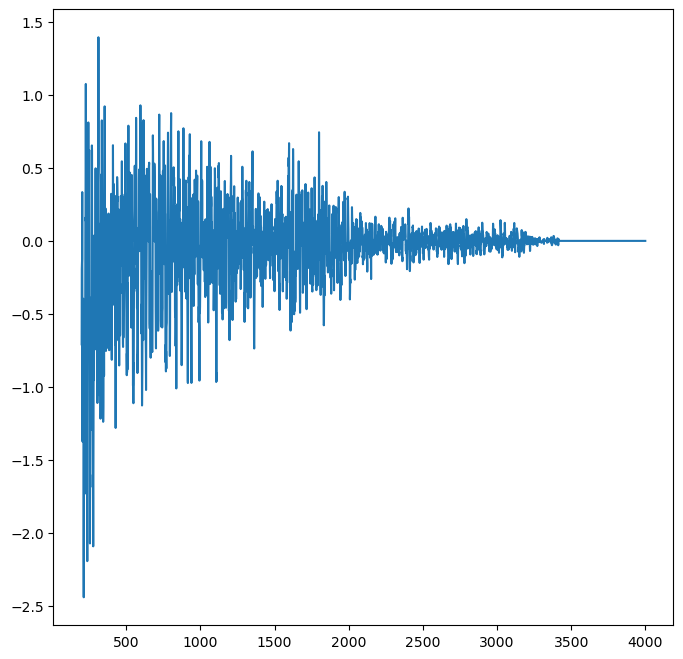

In [14]:
fig, ax = plt.subplots(figsize=(8,8))
ax.plot(energy_channel_array[200:4000], energy_spectrum_deriv[200:4000])

In [15]:
energy_spectrum_spline = UnivariateSpline(bin_energy_array, energy_spectrum_smooth)
energy_spectrum_spline_array = energy_spectrum_spline(bin_energy_array)
energy_spectrum_spline_deriv = energy_spectrum_spline.derivative()
energy_spectrum_spline_deriv_array = energy_spectrum_spline_deriv(bin_energy_array)

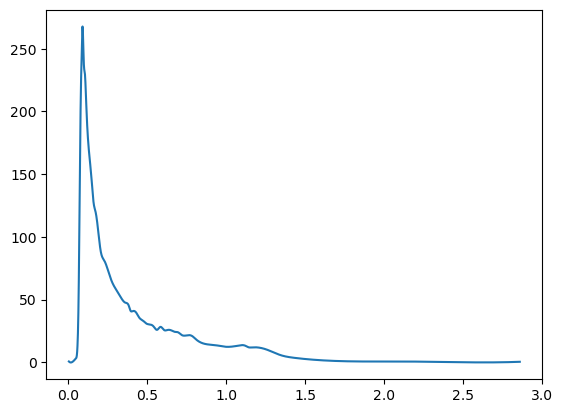

In [16]:
plt.plot(bin_energy_array, energy_spectrum_spline_array)

In [18]:
# peak finding
peaks, properties = find_peaks(-energy_spectrum_spline_deriv(bin_energy_array))
peaks

NameError: name 'energy_spectrum_spline_deriv' is not defined

In [17]:
# peak finding
peaks, properties = find_peaks(-energy_spectrum_spline_deriv(bin_energy_array), width=100, prominence=4)
print(peaks)
print(properties['prominences'])
print(properties['widths'])

NameError: name 'energy_spectrum_spline_deriv' is not defined

In [19]:
compton_edge = bin_energy_array[peaks[-1]]

Text(1.30673, 100, 'Compton Edge: 1.29673 MeVee')

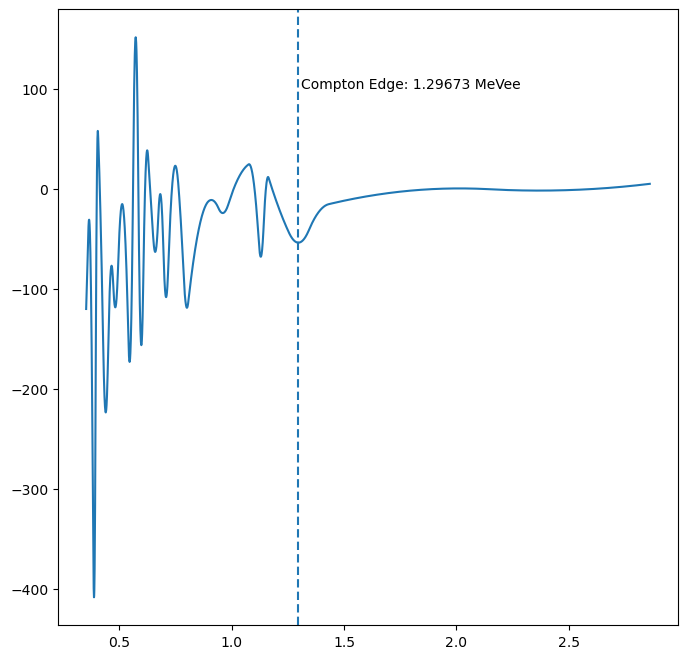

In [20]:
fig, ax = plt.subplots(figsize=(8,8))
ax.plot(bin_energy_array[500:], energy_spectrum_spline_deriv_array[500:])
ax.axvline(compton_edge, dashes=[4,2])
ax.text(compton_edge + 0.01, 100, f"Compton Edge: {compton_edge} MeVee")

Text(1.31673, 250, 'Compton Edge: 1.29673 MeVee')

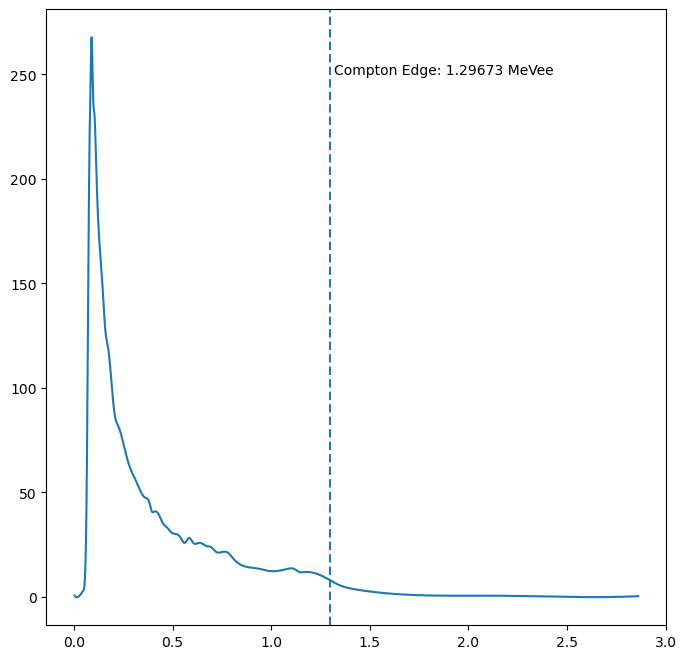

In [21]:
fig, ax = plt.subplots(figsize=(8,8))
ax.plot(bin_energy_array, energy_spectrum_spline_array)
ax.axvline(compton_edge, dashes=[4,2])
ax.text(compton_edge + 0.02, 250, f"Compton Edge: {compton_edge} MeVee")

(0.0, 40.0)

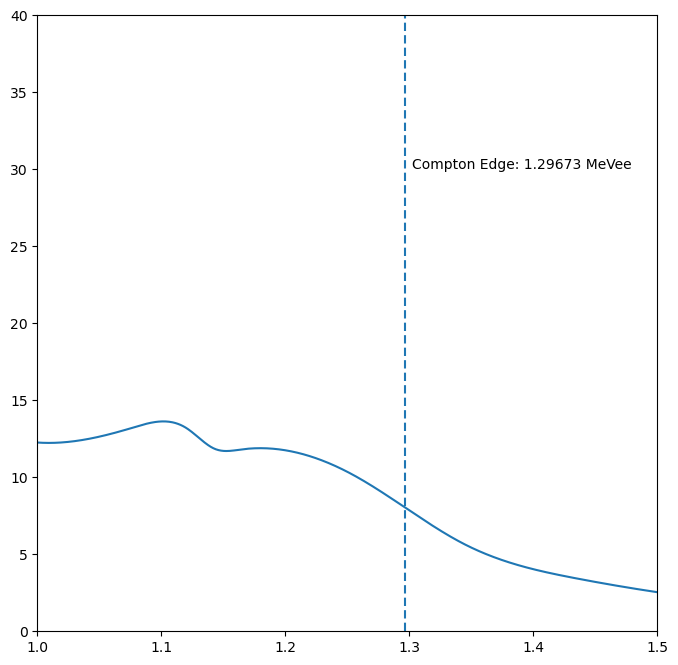

In [22]:
fig, ax = plt.subplots(figsize=(8,8))
ax.plot(bin_energy_array, energy_spectrum_spline_array)
ax.axvline(compton_edge, dashes=[4,2])
ax.text(compton_edge + 0.005, 30, f"Compton Edge: {compton_edge} MeVee")
ax.set_xlim(1.0, 1.5)
ax.set_ylim(0, 40)

In [7]:
energy_bin_width = 0.05

In [10]:
# Z, xe, ye = get_psd_energy_histogram(psd_report)
x = get_df_col(psd_report, DataframeColumn.CALIB_ENERGY)
y = get_df_col(psd_report, DataframeColumn.PSD)

max_energy = x.max()
print(max_energy)
energy_bins = np.arange(0, max_energy, energy_bin_width)
print(energy_bins)

Z, xe, ye = np.histogram2d(x, y, [energy_bins, 512])

2.36896
[0.   0.05 0.1  0.15 0.2  0.25 0.3  0.35 0.4  0.45 0.5  0.55 0.6  0.65
 0.7  0.75 0.8  0.85 0.9  0.95 1.   1.05 1.1  1.15 1.2  1.25 1.3  1.35
 1.4  1.45 1.5  1.55 1.6  1.65 1.7  1.75 1.8  1.85 1.9  1.95 2.   2.05
 2.1  2.15 2.2  2.25 2.3  2.35]


(<Figure size 1000x800 with 2 Axes>,
 <AxesSubplot: xlabel='Energy (MeVee)', ylabel='PSD'>)

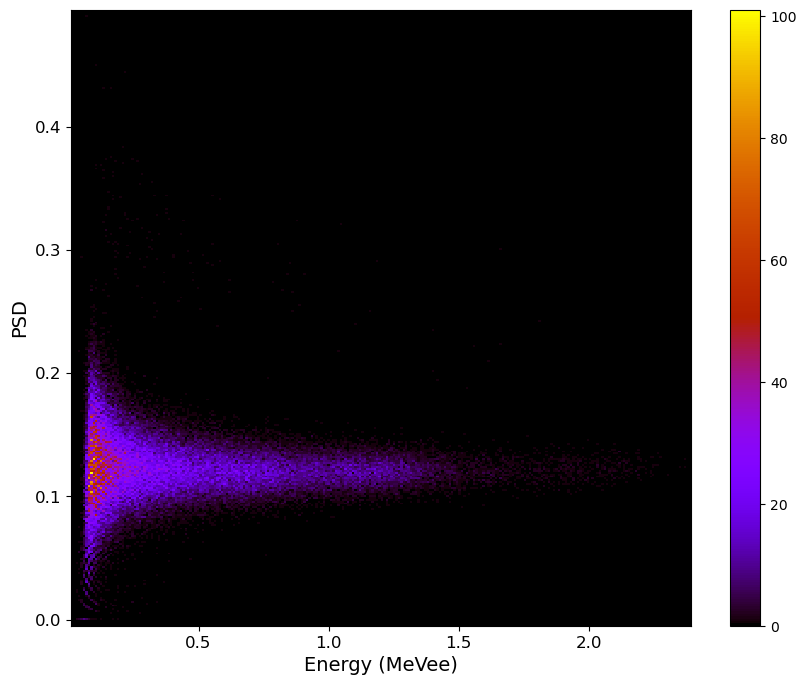

In [11]:
plot_psd_histogram(psd_report, colorbar=True)

(<Figure size 1000x800 with 1 Axes>, <AxesSubplot: >)

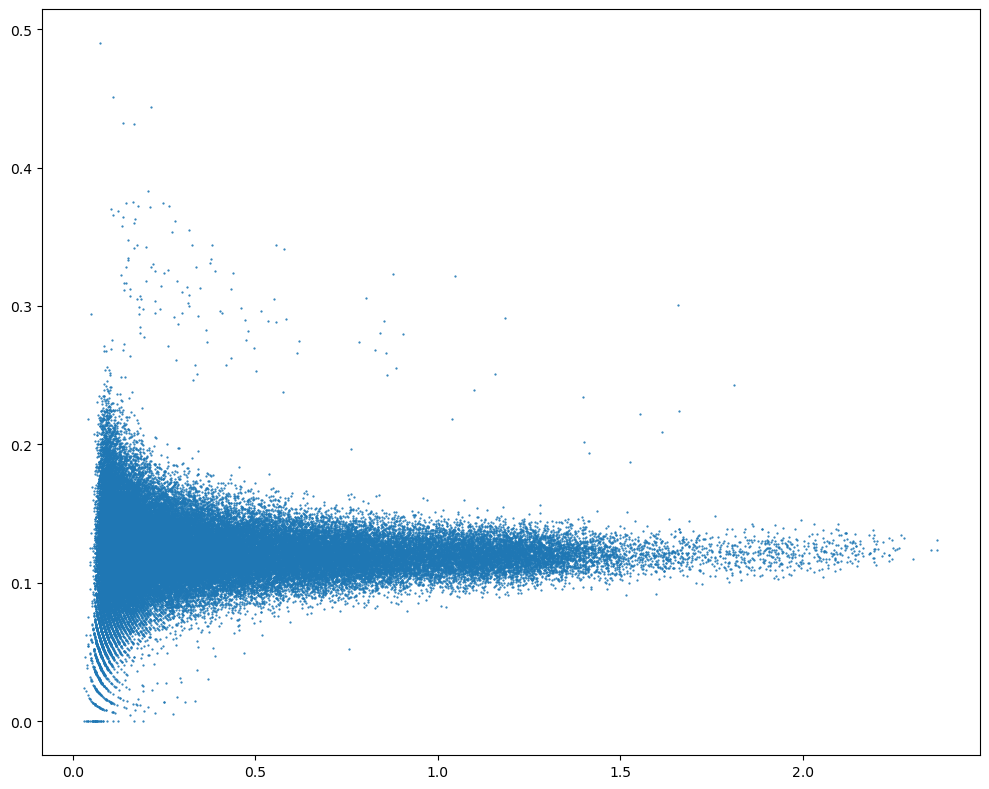

In [12]:
plot_scatter(psd_report["CALIB_ENERGY"], psd_report["tail / total"])

In [13]:
%%time
# Scan 2D histogram's energy slices and get bimodal fit

# Settings
start_scan_idx = 0
end_scan_idx = 420



end_scan_idx = min(end_scan_idx, len(Z))
psd_bin_lbs = ye[:-1]

# Default
default_bounds = (
    (0.1, 0.01, 1, 
     0.25, 0.01, 0),
    (0.2, 0.1, Z.max(),
     0.38, 0.04, 2000)
)

bounds_a = (
    (0.1, 0.01, 1, 
     0.35, 0.01, 0),
    (0.2, 0.1, Z.max(),
     0.36, 0.04, 2000)
)

bounds_b = (
    (0.1, 0.01, 1, 
     0.34, 0.01, 0),
    (0.2, 0.1, Z.max(),
     0.36, 0.03, 2000)
)


# Ranged Example
bounds = [
    ((0,60), bounds_a),
]

# df_fom = find_threshold_fom_slice(psd_bin_lbs, Z.T, bounds, 0, end_scan_idx)

df, df_err = scan_histogram_slices(
    psd_bin_lbs, 
    Z.T,
    bounds=bounds,
    default_bounds=default_bounds, 
    start_idx = start_scan_idx, 
    end_idx = end_scan_idx
)

df.head()

CPU times: user 52 ms, sys: 122 ms, total: 174 ms
Wall time: 607 ms


,i,mu1,sigma1,a1,mu2,sigma2,a2,fom
0,0,0.116588,0.010000,1.000000,0.354968,0.01,1.685751e-13,5.061517
1,1,0.119919,0.038579,103.390593,0.355053,0.01,1.445941e-03,2.055456
2,2,0.125680,0.032478,154.860907,0.350000,0.04,1.624507e-01,1.314335
3,3,0.123600,0.025997,120.531777,0.350000,0.04,1.559037e-01,1.456791
4,4,0.123455,0.021906,102.084023,0.350000,0.04,1.286489e-01,1.554056


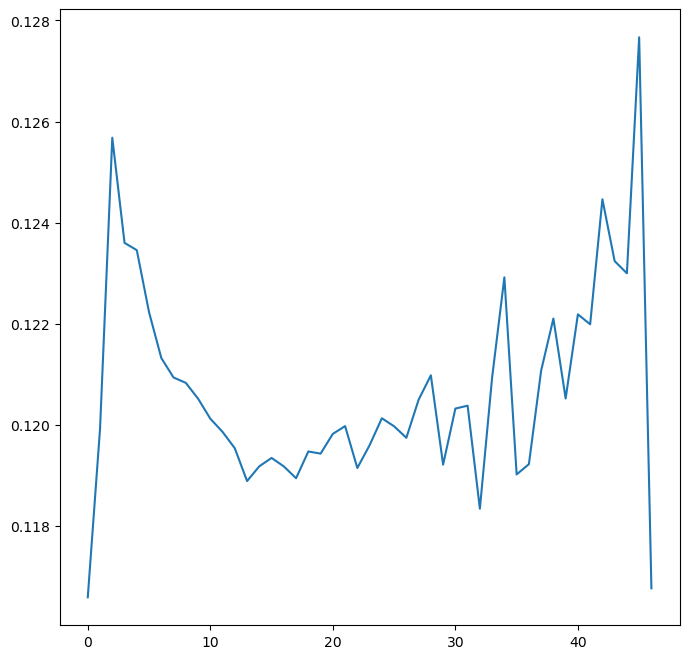

In [25]:
fig, ax = plt.subplots(figsize=(8,8))
ax.plot(df['i'], df['mu1'])
# ax.plot(df['i'], df['sigma1'])

In [15]:
usable_mu1 = df.query("i >= 10").query("i < 35")['mu1']
mu1_avg = usable_mu1.mean()
mu1_avg

0.11983694635909106

In [16]:
psd_slice_index = np.where(ye > mu1_avg)[0][0]
psd_slice_index

126

In [17]:
gamma_midpoint_slice = Z.T[psd_slice_index]
energy_axis = xe[:-1]

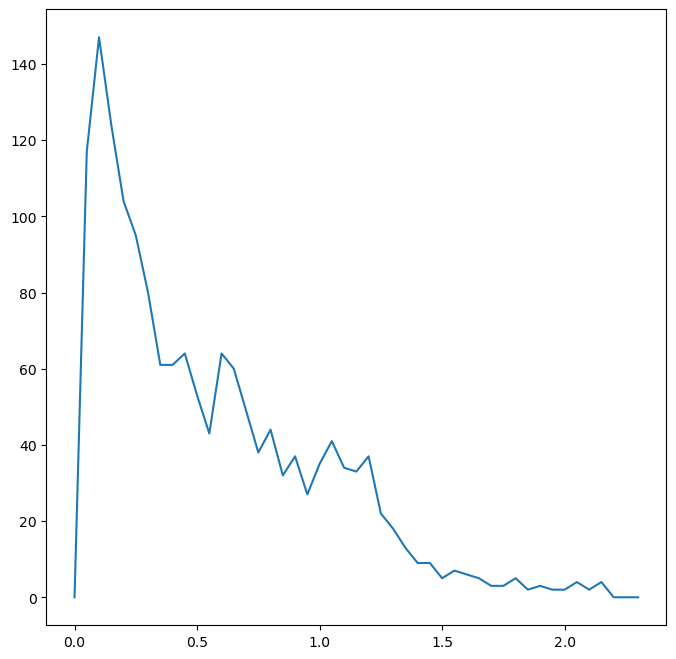

In [19]:
fig, ax = plt.subplots(figsize=(8,8))
ax.plot(energy_axis, gamma_midpoint_slice)

In [20]:
gamma_slice_smooth = savgol_filter(gamma_midpoint_slice, 11, 3)

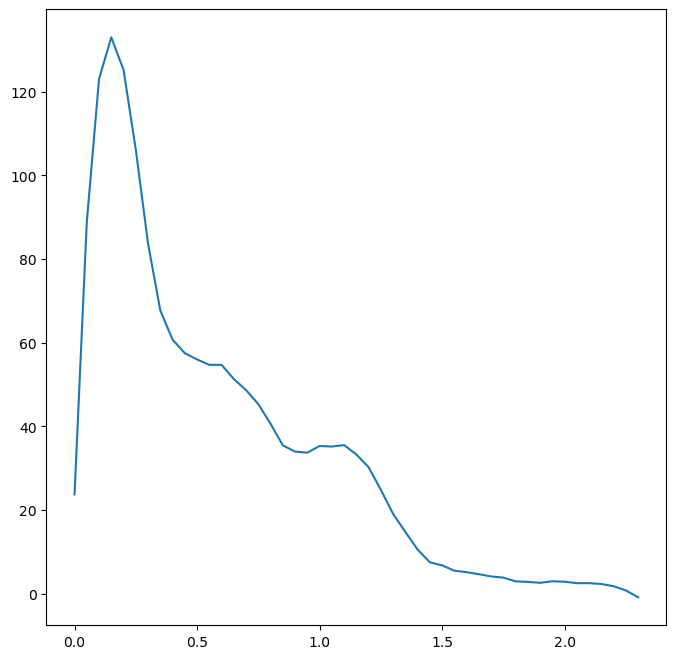

In [22]:
fig, ax = plt.subplots(figsize=(8,8))
ax.plot(energy_axis, gamma_slice_smooth)

In [44]:
energy_histo = Z.max(axis=1)

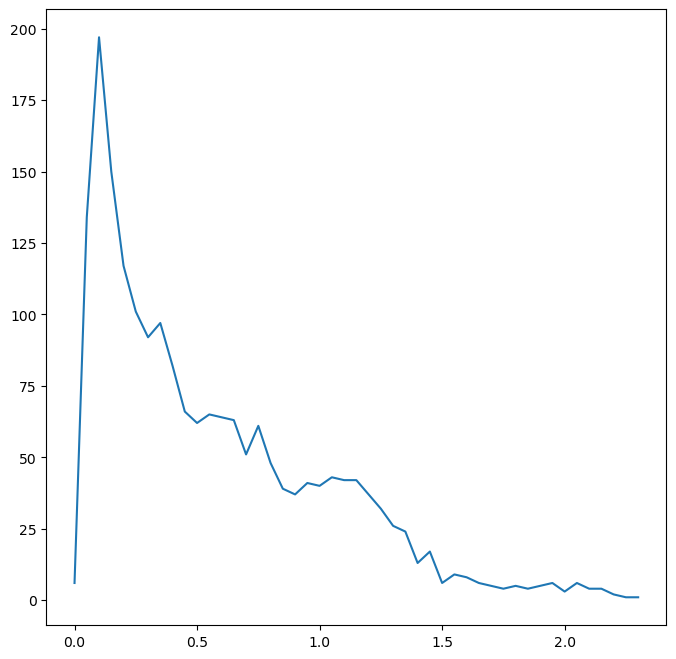

In [45]:
fig, ax = plt.subplots(figsize=(8,8))
ax.plot(energy_axis, energy_histo)

In [46]:
energy_histo_smooth = savgol_filter(energy_histo, 11, 3)

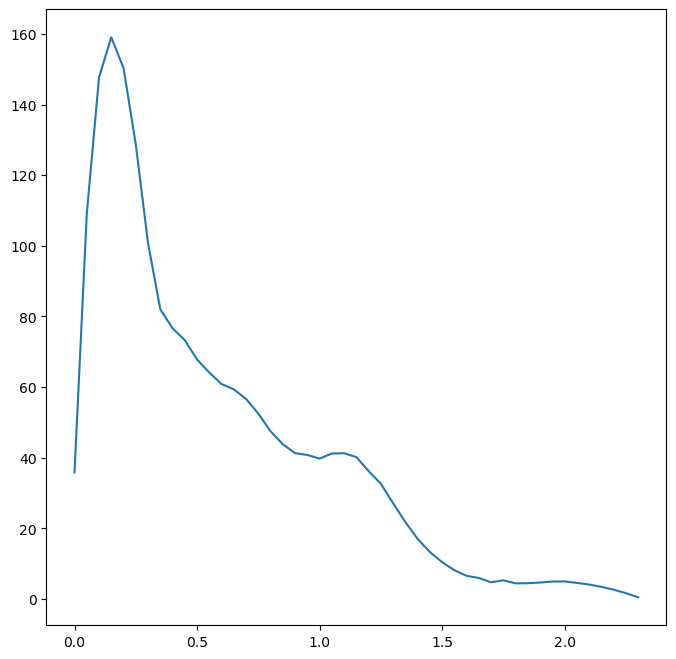

In [47]:
fig, ax = plt.subplots(figsize=(8,8))
ax.plot(energy_axis, energy_histo_smooth)

/opt/conda/lib/python3.10/site-packages/matplotlib/cbook/__init__.py:1369: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


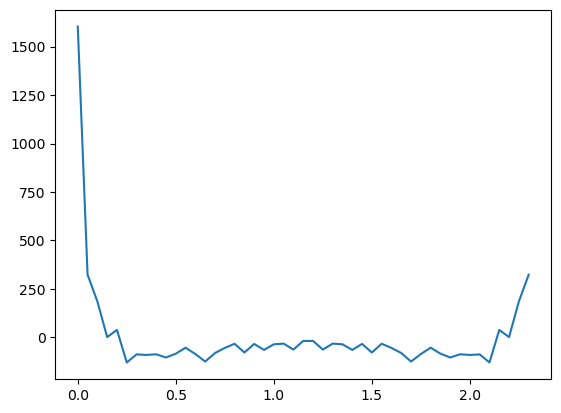

In [21]:
fft_spectrum = np.fft.fft(gamma_midpoint_slice)
plt.plot(energy_axis, fft_spectrum)

In [83]:
power_spectrum = np.abs(np.fft.fftshift(np.fft.fft(gamma_midpoint_slice)))**2

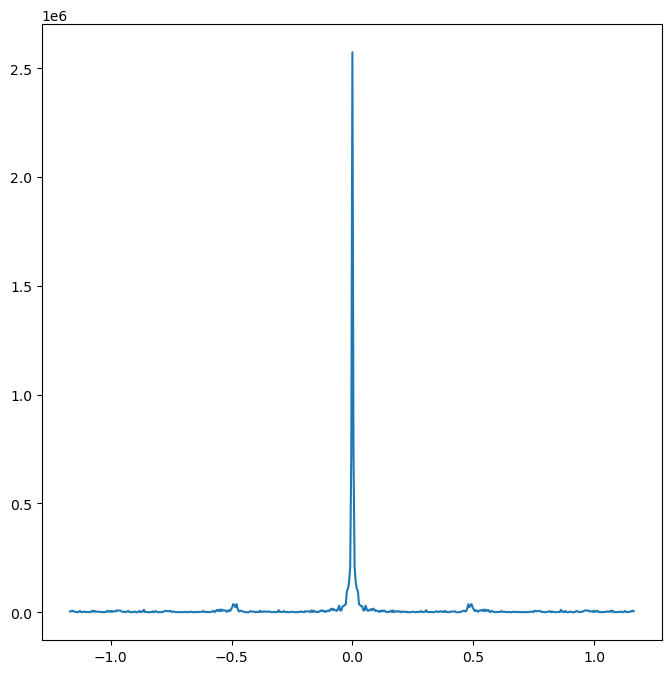

In [84]:
fourier_energy_axis = energy_axis - energy_axis[energy_axis.shape[0]//2]
fig, ax = plt.subplots(figsize=(8,8))
ax.plot(fourier_energy_axis, power_spectrum)

In [48]:
Z_psd_distro, edge_psd_distro = np.histogram(psd_report["tail / total"], bins=energy_bins)

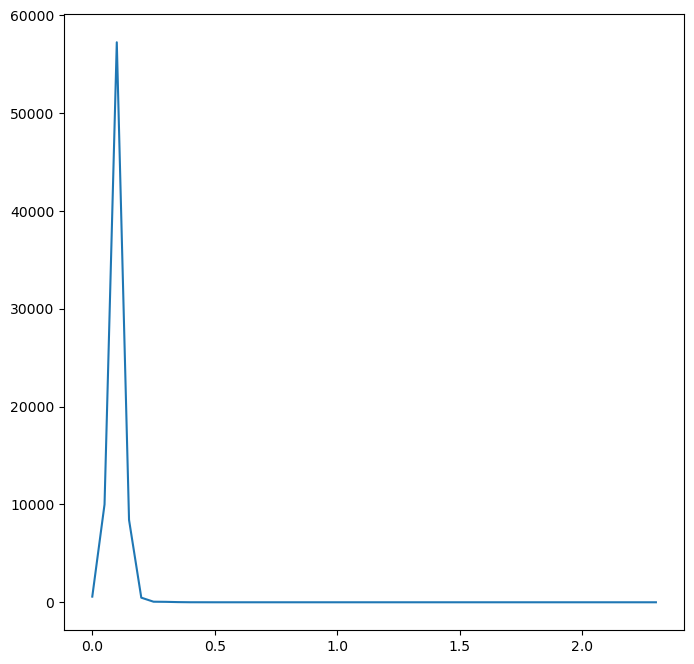

In [49]:
fig, ax = plt.subplots(figsize=(8,8))
ax.plot(edge_psd_distro[:-1], Z_psd_distro)